## Data Visualization

In [1]:
import pandas as pd
pd.options.display.float_format = "{:,.2f}".format

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/dummy_data.csv')
df.head()

,customer_id,age,region,segment,income,monthly_spend
0,1,56,West,Medium Value,"63,353.00","2,411.00"
1,2,69,East,Medium Value,"64,900.00","2,688.00"
2,3,46,East,Low Value,"47,074.00","1,147.00"
3,4,32,North,High Value,"30,267.00","1,671.00"
4,5,60,North,High Value,"44,233.00","2,753.00"


### Grammer of Graphics

    1. Data: df
    2. Aesthetics
        A. x-axis:
        B. y-axis:

In [3]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install -U nbformat

Note: you may need to restart the kernel to use updated packages.


In [6]:
import plotly.express as px

fig = px.scatter(
    data_frame=df, # data
    x="age", # x aesthetic
    y="income", # y aesthetic
    color="segment", # color aesthetic
    size="monthly_spend", # size aesthetic
    # facet_row ="region", # facet

    facet_col="region",
    trendline="ols", # statistical layer
    title="Relationship Between Customer Age and Income"
)

fig.show()

In [20]:
grouping = ["region","segment"]
sales_by_region= df.groupby(grouping, as_index = False).agg(
     total_sales= ('monthly_spend', 'sum'),
     avg_age= ('age', 'mean'),
     avg_income= ('income', 'mean'),
     number_of_customers= ('customer_id', 'count')
)
sales_by_region.head()

,region,segment,total_sales,avg_age,avg_income,number_of_customers
0,East,High Value,"30,380.00",35.64,"45,427.64",11
1,East,Low Value,"41,203.00",39.44,"51,505.31",32
2,East,Medium Value,"45,082.00",46.14,"54,797.90",21
3,North,High Value,"37,696.00",40.93,"44,810.29",14
4,North,Low Value,"36,642.00",45.08,"56,712.85",26


In [21]:
Y = list(sales_by_region.columns)[len(grouping):]
Y

['total_sales', 'avg_age', 'avg_income', 'number_of_customers']

In [24]:
Y = ['total_sales', 'avg_age', 'avg_income', 'number_of_customers']

for i in Y:
    fig= px.bar(
        data_frame= sales_by_region,
        x= 'region',
        y=i,
        title= f'{i} by Region'
    )
    fig.show()    

### Matplotlib for Instacart

In [25]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [28]:
df = pd.read_parquet('../data/processed/instacart.parquet')
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.00,1,1,Soda,9.00,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.00,2,1,Organic String Cheese,8.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.00,3,1,0% Greek Strained Yogurt,12.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.00,4,1,XL Pick-A-Size Paper Towel Rolls,1.00,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.00,5,1,Milk Chocolate Almonds,6.80,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [29]:
df.shape

(1384706, 22)

In [39]:
df.describe().iloc[:,1]

count   1,384,706.00
mean           17.09
std            16.61
min             4.00
25%             6.00
50%            11.00
75%            21.00
max           100.00
Name: order_number, dtype: float64

In [35]:
df.describe()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,"1,384,706.00","1,384,706.00","1,384,706.00","1,384,706.00","1,384,706.00","1,384,706.00","1,384,706.00","1,384,618.00","1,384,706.00","1,384,706.00","1,384,706.00"
mean,"1,706,297.96",17.09,2.70,13.58,17.07,8.76,0.60,14.12,49.38,1.50,"97,662.28"
std,"989,734.21",16.61,2.17,4.24,10.43,7.42,0.49,680.23,18.44,1.12,"41,991.39"
min,1.00,4.00,0.00,0.00,0.00,1.00,0.00,1.00,18.00,0.00,"25,911.00"
25%,"843,370.00",6.00,1.00,10.00,7.00,3.00,0.00,4.30,33.00,0.00,"64,859.00"
50%,"1,701,880.00",11.00,3.00,14.00,15.00,7.00,1.00,7.40,49.00,1.00,"95,765.00"
75%,"2,568,023.00",21.00,5.00,17.00,30.00,12.00,1.00,11.30,65.00,2.00,"126,817.75"
max,"3,421,070.00",100.00,6.00,23.00,30.00,80.00,1.00,"99,999.00",81.00,3.00,"591,089.00"


In [41]:
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.00,1,1,Soda,9.00,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.00,2,1,Organic String Cheese,8.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.00,3,1,0% Greek Strained Yogurt,12.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.00,4,1,XL Pick-A-Size Paper Towel Rolls,1.00,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.00,5,1,Milk Chocolate Almonds,6.80,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [ ]:
df_dow= (
    df[['order_id','order_dow']].
    drop_duplicates().
    groupby("order_dow").
    size()
)
df_dow

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [43]:
type(df_dow)

pandas.Series

In [44]:
X = df_dow.index
Y = df_dow.values

In [45]:
type(Y)

numpy.ndarray

In [46]:
type(X)

pandas.Index

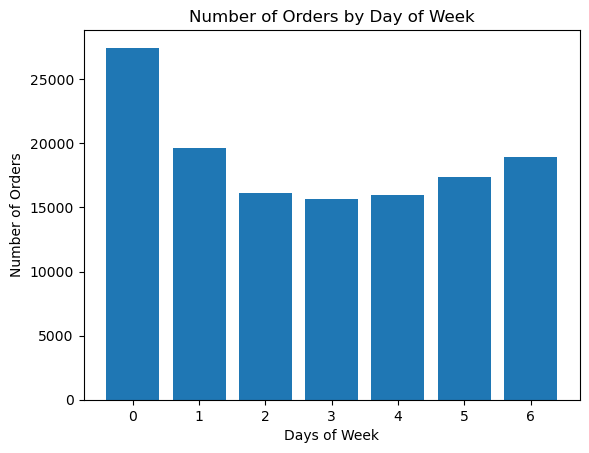

In [52]:
plt.figure()
plt.bar(x=X,height = Y)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Days of Week")
plt.ylabel("Number of Orders")
plt.show()

In [53]:
df_hod = (
    df[['order_id','order_hour_of_day']]
    .drop_duplicates()
    .groupby('order_hour_of_day')
    .size()
    )


df_hod

order_hour_of_day
0       852
1       507
2       305
3       223
4       218
5       402
6      1121
7      3376
8      6343
9      9033
10    10585
11    10610
12    10622
13    10711
14    11103
15    11075
16    10495
17     9353
18     7558
19     5721
20     3978
21     3050
22     2442
23     1526
dtype: int64

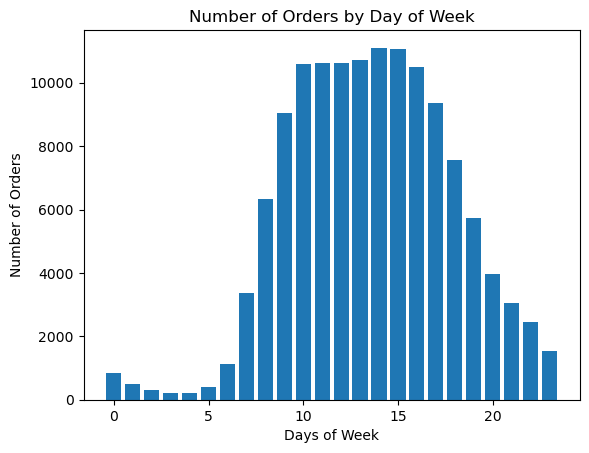

In [57]:
X=df_hod.index
Y=df_hod.values
plt.figure()
plt.bar(x=X, height=Y)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Days of Week")
plt.ylabel("Number of Orders")
plt.show()

In [58]:
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.00,1,1,Soda,9.00,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.00,2,1,Organic String Cheese,8.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.00,3,1,0% Greek Strained Yogurt,12.60,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.00,4,1,XL Pick-A-Size Paper Towel Rolls,1.00,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.00,5,1,Milk Chocolate Almonds,6.80,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [69]:
df_hod= (
    df[['order_id','order_hour_of_day']]
    .drop_duplicates()
    .groupby('order_hour_of_day')
    .size()
    )
df_hod

order_hour_of_day
0       852
1       507
2       305
3       223
4       218
5       402
6      1121
7      3376
8      6343
9      9033
10    10585
11    10610
12    10622
13    10711
14    11103
15    11075
16    10495
17     9353
18     7558
19     5721
20     3978
21     3050
22     2442
23     1526
dtype: int64

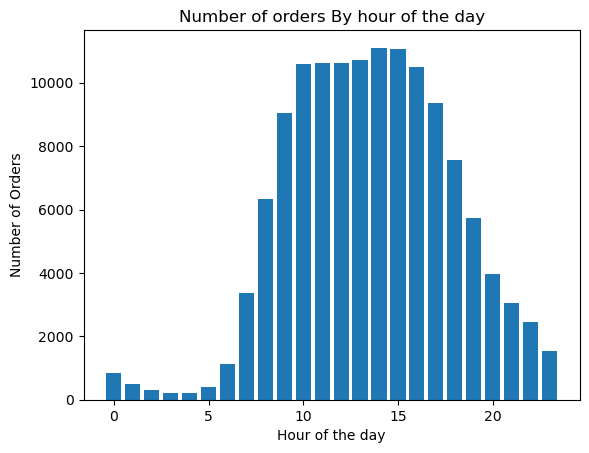

In [78]:
X=df_hod.index
Y=df_hod.values
plt.figure()
plt.bar(x=X, height=Y)
plt.title('Number of orders By hour of the day')
plt.xlabel("Hour of the day")
plt.ylabel("Number of Orders")
plt.show()

In [79]:
top_departments  = df['department'].value_counts().head(10)

top_departments

department
produce            409087
dairy eggs         217051
snacks             118862
beverages          113962
frozen             100426
pantry              81242
bakery              48394
canned goods        46799
deli                44291
dry goods pasta     38713
Name: count, dtype: int64

In [88]:
N = 5

if df['department'].value_counts().shape[0] > 10:
    departments  = df['department'].value_counts().head(N)
else:
    departments  = df['department'].value_counts().tail(N)
    

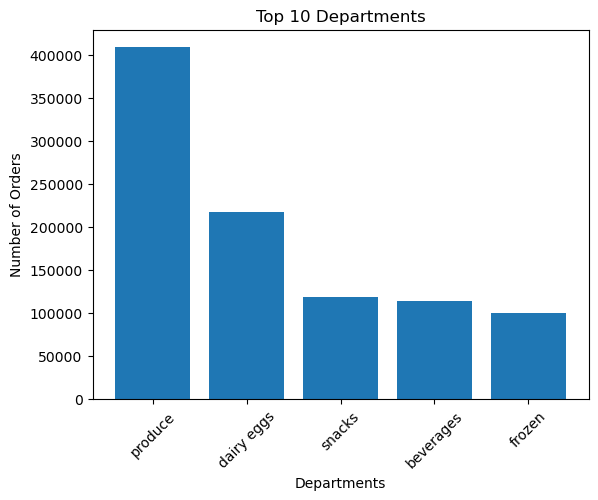

In [85]:
X = departments.index
Y = departments.values




plt.figure()
plt.bar(x=X,height = Y)
plt.title("Top 10 Departments")
plt.xlabel("Departments")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)
plt.show()

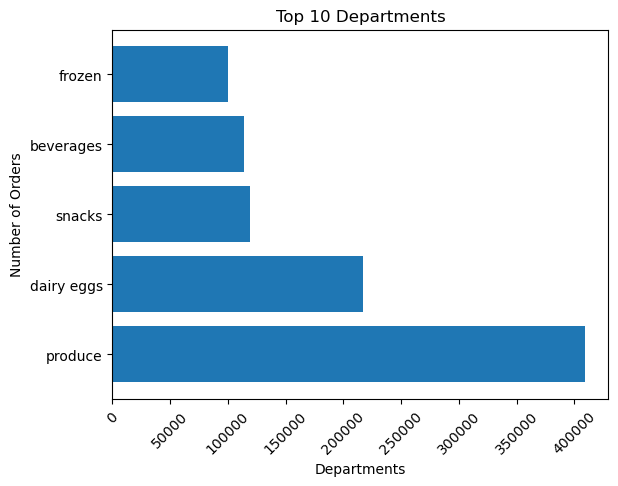

In [90]:
plt.figure()
plt.barh(y=X,width= Y)
plt.title("Top 10 Departments")
plt.xlabel("Departments")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)
plt.show()

In [95]:
df['prices'].describe()

count   1,384,618.00
mean           14.12
std           680.23
min             1.00
25%             4.30
50%             7.40
75%            11.30
max        99,999.00
Name: prices, dtype: float64

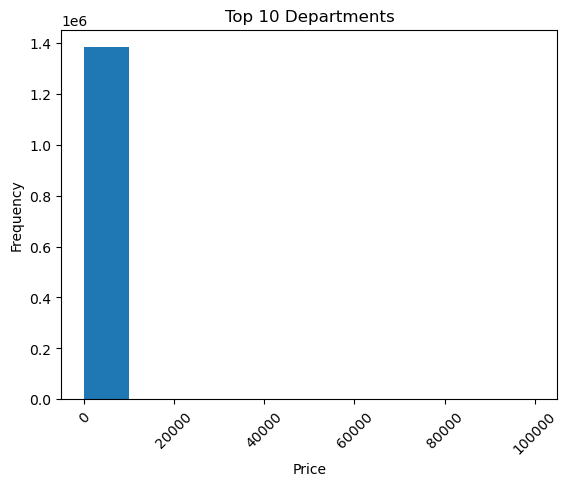

In [99]:
plt.figure()
plt.hist(df['prices'].dropna())
plt.title("Top 10 Departments")
plt.xlabel("Price")
plt.Artist()
plt.ylabel("Frequency")
plt.xticks(rotation = 45)
plt.show()

In [102]:
upper_limit = df['prices'].quantile(0.99)
upper_limit

np.float64(18.1)

In [107]:
df_prices_q= df[df['prices']<= 18.1]
df_prices_q["prices"].describe()

count   1,370,887.00
mean            7.67
std             4.04
min             1.00
25%             4.20
50%             7.30
75%            11.20
max            18.10
Name: prices, dtype: float64

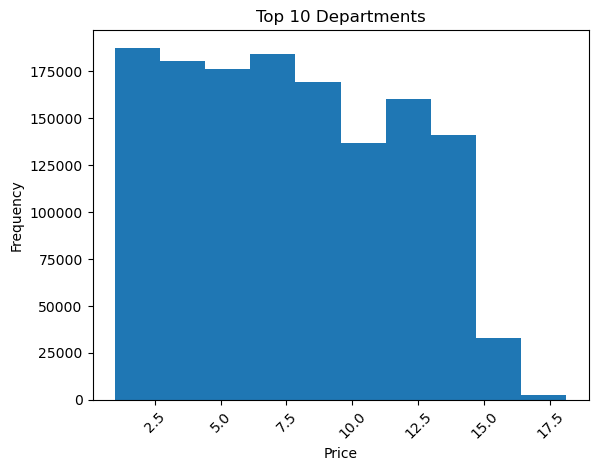

In [108]:
plt.figure()
plt.hist(df_prices_q['prices'].dropna())
plt.title("Top 10 Departments")
plt.xlabel("Price")
plt.Artist()
plt.ylabel("Frequency")
plt.xticks(rotation = 45)
plt.show()


In [109]:
df['prices'].describe()

count   1,384,618.00
mean           14.12
std           680.23
min             1.00
25%             4.30
50%             7.40
75%            11.30
max        99,999.00
Name: prices, dtype: float64

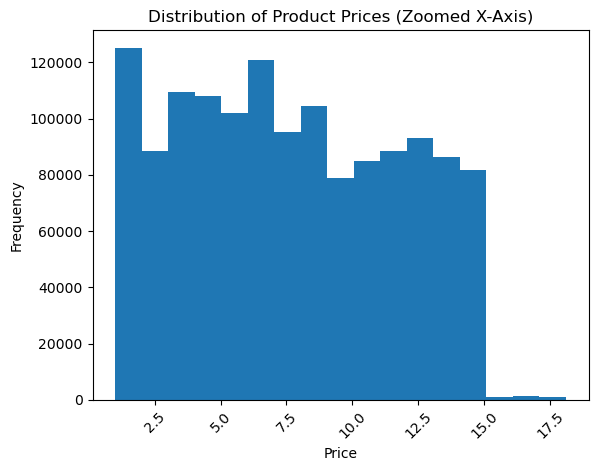

In [113]:
plt.figure()
plt.hist(df_prices_q["prices"].dropna(), bins=17)
plt.title("Distribution of Product Prices (Zoomed X-Axis)")
plt.xlabel("Price")
# plt.Artist()
plt.ylabel("Frequency")
plt.xticks(rotation = 45)
plt.show()
